In [184]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [186]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

In [188]:
!pip install tensorflow

In [190]:
#SET PATHS
photos_dir = 'photos'  # Directory containing photo files
photos_json = 'photos.json'  # Path to JSON file
output_dir = 'preprocessed_data'  # Where to save processed data
os.makedirs(output_dir, exist_ok=True)

In [194]:
# Constants
IMG_SIZE = 128  # For CNN
MAX_IMAGES = 50000

# Load JSONL file (each line is a JSON object)
photos_data = []
with open(photos_json, 'r') as f:
    for line in f:
        try:
            photos_data.append(json.loads(line.strip()))
        except json.JSONDecodeError as e:
            print(f'Error parsing line: {e}')
            continue

# Convert to DataFrame
photos_df = pd.DataFrame(photos_data)
photos_df = photos_df.sample(n=20000, random_state=42).reset_index(drop=True)

print('Sampled DataFrame shape:', photos_df.shape)
print(photos_df.head())


Sampled DataFrame shape: (20000, 4)
                 photo_id             business_id              caption  label
0  k_PSngRS22mSA1MypwrjPg  DzzVSYXadZ1_XgfGz_Loyw  Chocolate Croissant   food
1  D_94KivwVgitkzFIgE_KcQ  Xdzir62WKlSzeu4PMQtlBA                        food
2  Hf39P7_G_eRCqfVwvMDV6g  z0HzwNBmx_BgdiYI4hLk3g    Happy Anniversary  drink
3  agxl4sABeRXwjLL506KMrQ  HzRSWmNxcEVQGrr1tun25w       Frozen Puccino   food
4  7cZ0MREN2TwAAX4nnirQlA  aj0urA2r2WlqZKufeB5dpw  Double Cheeseburger   food


In [196]:
# Label distribution
print("\nLabel distribution:\n", photos_df['label'].value_counts())

# Check missing values and caption lengths
print("\nMissing captions:", photos_df['caption'].isnull().sum())
print("\nCaption length stats:\n", photos_df['caption'].str.len().describe())


Label distribution:
 label
food       10877
inside      5550
outside     1850
drink       1550
menu         173
Name: count, dtype: int64

Missing captions: 0

Caption length stats:
 count    20000.000000
mean        14.999000
std         24.376036
min          0.000000
25%          0.000000
50%          0.000000
75%         21.000000
max        140.000000
Name: caption, dtype: float64


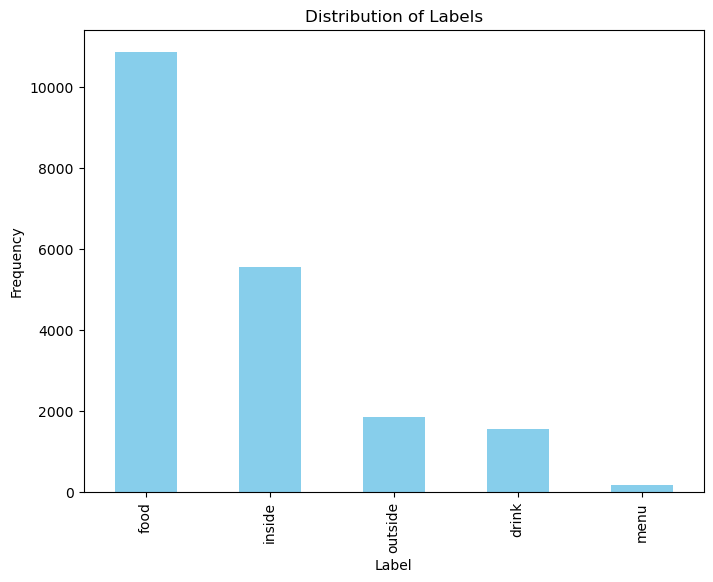

In [198]:
# Plot label distribution
import matplotlib.pyplot as plt

label_counts = photos_df['label'].value_counts()
plt.figure(figsize=(8, 6))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.show()

<Figure size 1000x600 with 0 Axes>

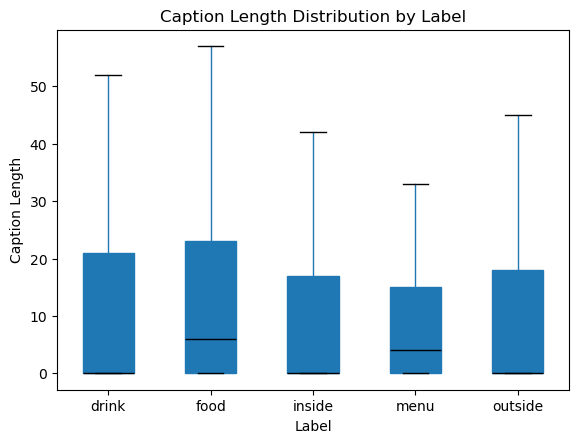

In [200]:
# Caption length boxplot
photos_df['caption_length'] = photos_df['caption'].str.len()
plt.figure(figsize=(10, 6))
photos_df.boxplot(column='caption_length', by='label', grid=False, showfliers=False, patch_artist=True, medianprops={'color': 'black'})
plt.title('Caption Length Distribution by Label')
plt.suptitle('')
plt.xlabel('Label')
plt.ylabel('Caption Length')
plt.show()

In [202]:
# Unique businesses by label
business_by_label = photos_df.groupby('label')['business_id'].nunique()
print("\nUnique businesses per label:\n", business_by_label)


Unique businesses per label:
 label
drink      1382
food       7458
inside     4239
menu        166
outside    1559
Name: business_id, dtype: int64


In [204]:
# Encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
photos_df['label'] = le.fit_transform(photos_df['label'])

In [206]:
# Process images
images = []
labels = []
skipped_count = 0
total = min(MAX_IMAGES, len(photos_df))

print(f"\nTotal images to process: {total}")

for i, row in enumerate(photos_df.itertuples(index=False)):
    if i >= MAX_IMAGES:
        break

    img_path = os.path.join(photos_dir, f"{row.photo_id}.jpg")  #  use photo_id

    try:
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
            img_array = np.asarray(img, dtype=np.float32) / 255.0  # Normalize
            images.append(img_array)
            labels.append(row.label)
    except Exception as e:
        skipped_count += 1
        print(f"Failed to process {img_path}: {e}")

    if i % (total // 20 or 1) == 0 or i == total - 1:
        percent = (i + 1) / total * 100
        print(f"Progress: {percent:.1f}% ({i + 1}/{total})", end='\r')

print(f"\n\nFinished processing {len(images)} images.")
print(f"Skipped {skipped_count} corrupted/unreadable images.")


Total images to process: 20000
Failed to process photos\1MOGQBWogR8oJr1WgERi9g.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\1MOGQBWogR8oJr1WgERi9g.jpg'
Failed to process photos\pW1IPuTdLIUB61goirbXaA.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\pW1IPuTdLIUB61goirbXaA.jpg'
Failed to process photos\CBxmBYD_5CXIL_F-2PDqmA.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\CBxmBYD_5CXIL_F-2PDqmA.jpg'
Failed to process photos\W94rrCn0O5K1lkfD26m4tw.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\W94rrCn0O5K1lkfD26m4tw.jpg'
Failed to process photos\7xcWPjcE4mxoQ1AjvvKJZg.jpg: cannot identify image file 'C:\\Users\\aniru\\Downloads\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos\\7xcWPjcE4mxoQ1AjvvKJZg.jpg'
Failed to process photos\JZZ716oX6_MqH6L_Mk

In [208]:
test_path = os.path.join(photos_dir, f"{photos_df.iloc[0].photo_id}.jpg")
print("Test path:", test_path)

try:
    with Image.open(test_path) as img:
        img = img.convert('RGB')
        img = img.resize((64, 64))
        img_array = np.asarray(img, dtype=np.float32) / 255.0
        print("Image shape:", img_array.shape)
except Exception as e:
    print("Error:", e)


Test path: photos\k_PSngRS22mSA1MypwrjPg.jpg
Image shape: (64, 64, 3)


In [210]:
# 1. Flatten image arrays
X = np.array(images).reshape(len(images), -1)  # (num_samples, 64*64*3)
y = np.array(labels)


In [71]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


In [73]:
#create sample data if you're just testing
import numpy as np
X = np.random.rand(100, 4)  # Create 100 samples with 4 features
y = np.random.randint(0, 2, 100)  # Binary target variable

# Now split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [75]:
# 3. Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)


KNeighborsClassifier()

In [77]:
# 4. Predict and evaluate
y_pred = knn.predict(X_test)


In [79]:
print("\n--- Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


--- Evaluation ---
Accuracy: 0.60
Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.70      0.64        10
           1       0.62      0.50      0.56        10

    accuracy                           0.60        20
   macro avg       0.60      0.60      0.60        20
weighted avg       0.60      0.60      0.60        20



In [88]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array

# Load ResNet50 up to the "avg_pool" layer
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
model = Model(inputs=base_model.input, outputs=base_model.output)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [97]:
images = []
labels = []

for i, row in enumerate(photos_df.itertuples(index=False)):
    img_path = os.path.join(photos_dir, f"{row.photo_id}.jpg")

    try:
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            img = img.resize((224, 224))  # required size for ResNet
            img_array = img_to_array(img)
            img_array = preprocess_input(img_array)
            images.append(img_array)
            labels.append(row.label)
    except Exception as e:
        continue

X = np.array(images)
y = np.array(labels)


# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier


In [118]:
# Define your parameter grid
param_grid = {
    'n_neighbors': list(range(1, 21)),          # Try 1 to 20 neighbors
    'weights': ['uniform', 'distance'],         # Weight strategies
    'metric': ['euclidean', 'manhattan']        # Distance metrics
}

# Initialize model
knn = KNeighborsClassifier()

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit the search
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)


Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best Accuracy Score: 0.6125


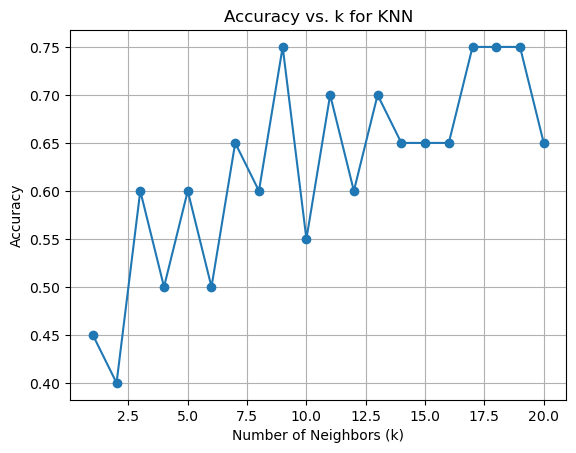

In [120]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

k_range = range(1, 21)
accuracies = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

plt.plot(k_range, accuracies, marker='o')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. k for KNN')
plt.grid(True)
plt.show()


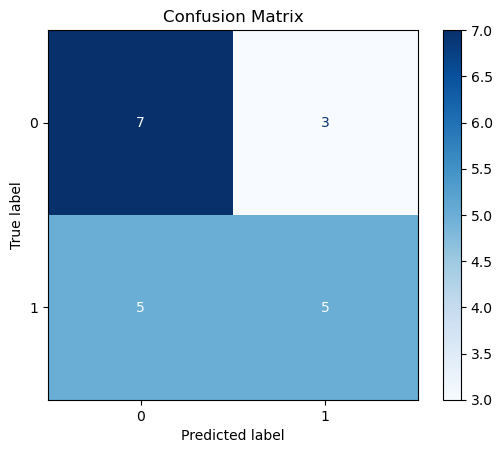

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt  # Also adding matplotlib import to be safe

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

AUC Score: 0.605


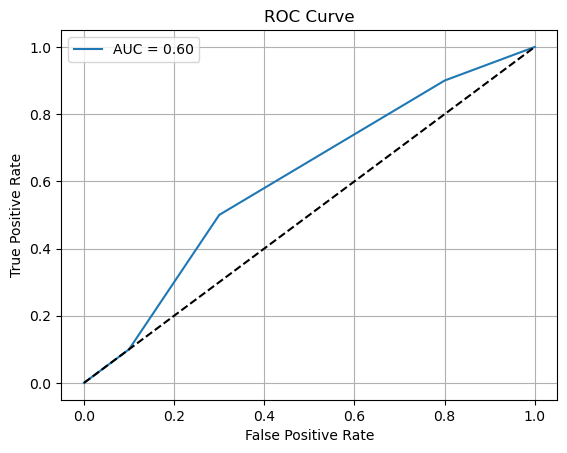

In [100]:
# Import the required functions from scikit-learn
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt  # Also adding this import in case it's missing

# y_pred_proba gives probability for both classes. Take [:,1] for positive class
y_score = knn.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_score)
print("AUC Score:", auc_score)

# Optional: plot ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_score)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

In [114]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np

# Step 1: Convert labels to binary matrix
classes = np.unique(y_test)

# Check if binary or multi-class classification
if len(classes) == 2:
    # For binary classification, use the raw probabilities of the positive class
    y_score = knn.predict_proba(X_test)[:, 1]  # Use probability of positive class only
    auc_score = roc_auc_score(y_test, y_score)
    print("AUC (binary):", auc_score)
else:
    # For multi-class, use label_binarize
    y_test_bin = label_binarize(y_test, classes=classes)
    y_score = knn.predict_proba(X_test)
    
    # Step 2: Calculate macro-average AUC
    auc_score = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
    print("Macro-Averaged AUC (OvR):", auc_score)

AUC (binary): 0.605
